## **Notebook 1 — Disaster Tweet Classification - EDA**

In this notebook, we explore the dataset and understand:
- Data distribution
- Class imbalance
- Text characteristics

### **IMPORTING MODULES/LIBRARIES**
This section will import all the libraries or modules required to add details in the cleaning and EDA process.

In [139]:
import io
import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from pathlib import Path
from wordcloud import WordCloud

### Logger Configuration

This project uses Python logging instead of print statements.

Why?
- Debugging large datasets
- Tracking preprocessing steps
- Production ML pipelines
- Helps identify where a failure occurred

All activities will be recorded inside:
data_preparation.log

In [140]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "data_preparation.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8")
    ],
    force=True
)

logger = logging.getLogger(__name__)

logger.info("==== DATA PREPARATION PIPELINE STARTED ====")
print(f"Logging to: {LOG_FILE}")


Logging to: E:\DData\Projects\DSC\NextHikes\Python\disaster-tweet-classification-nlp-pro-7\logs\data_preparation.log


### **SECTION 1 - CLEANING TRAIN DATASET**

Objective:
In this step, we clean and normalize tweet text to improve model performance.

In [141]:
logger.info("Downloading NLTK resources...")
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
logger.info("NLTK resources downloaded and initialized.")

[nltk_data] Downloading package stopwords to C:\Users\Aishwarya Kr
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Load Data

In [142]:
logger.info("Loading CSV file...")
DATA_PATH = Path("../data/twitter_disaster.csv")
df = pd.read_csv(DATA_PATH)
logger.info(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


#### **WordCloud Visualization**

This visualization generates a **WordCloud** from tweets labeled as disaster-related (`target = 1`) to highlight the most frequently occurring words in that subset of the dataset.

### What this code does
- Filters the dataset to include only disaster tweets
- Combines all tweet text into a single string
- Creates a WordCloud with a white background
- Displays the visualization using Matplotlib
- Logs the progress before and after generation

### Purpose
The WordCloud provides a quick visual summary of dominant terms in disaster-related tweets, which can help identify common themes, keywords, and patterns in the text data.


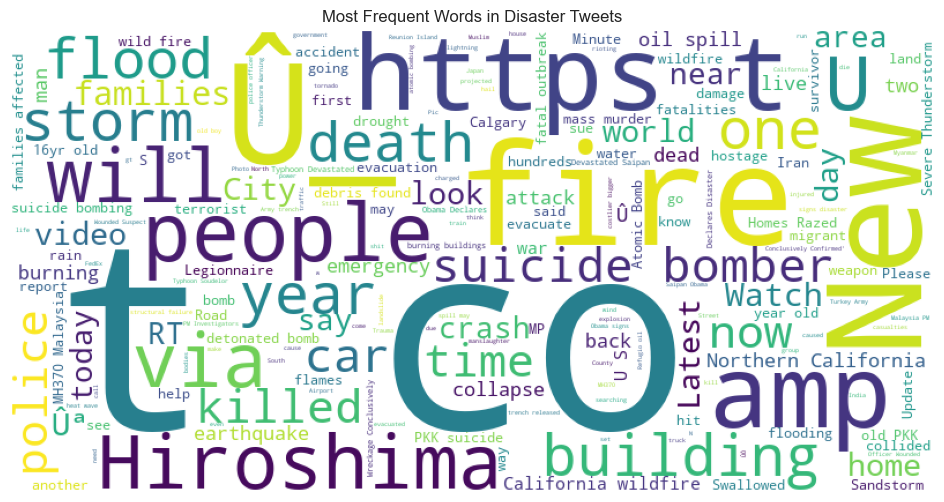

In [143]:
# WordCloud Visualization
logger.info("Generating word cloud for disaster tweets...")
disaster_text = " ".join(df[df["target"]==1]["text"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(disaster_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Disaster Tweets")
plt.show()
logger.info("Word cloud generated and displayed.")

#### Dataset Meta Data

In [144]:
logger.info("Data previewed with head().")
logger.info("Data shape: %s", df.shape)
logger.info("Columns: %s", df.columns.tolist())
logger.info("Data types:\n%s", df.dtypes)

#### **Dataset Overview**

The dataset includes the following columns:
- `id`: a unique identifier assigned to each tweet
- `keyword`: a disaster-related term associated with the tweet, when available
- `location`: the user-provided location, if mentioned
- `text`: the original tweet content
- `target`: the classification label, where `1` indicates a disaster tweet and `0` indicates a non-disaster tweet


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


#### Handling Missing Values

In [146]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

#### Target distribution detail
We will see the target distribution details as shown below. This will help in identifying the data before and after cleaning.

In [147]:
# Basic target distribution
target_counts = df["target"].value_counts().sort_index()
target_counts.index = ["Non-Disaster (0)", "Disaster (1)"] 
logger.info("Target distribution:\n%s", target_counts)

#### Plotting target distribution
Here we will see the graphical representation of the target distribution, whci classifies it into Disaster and Non-Disaster categories.

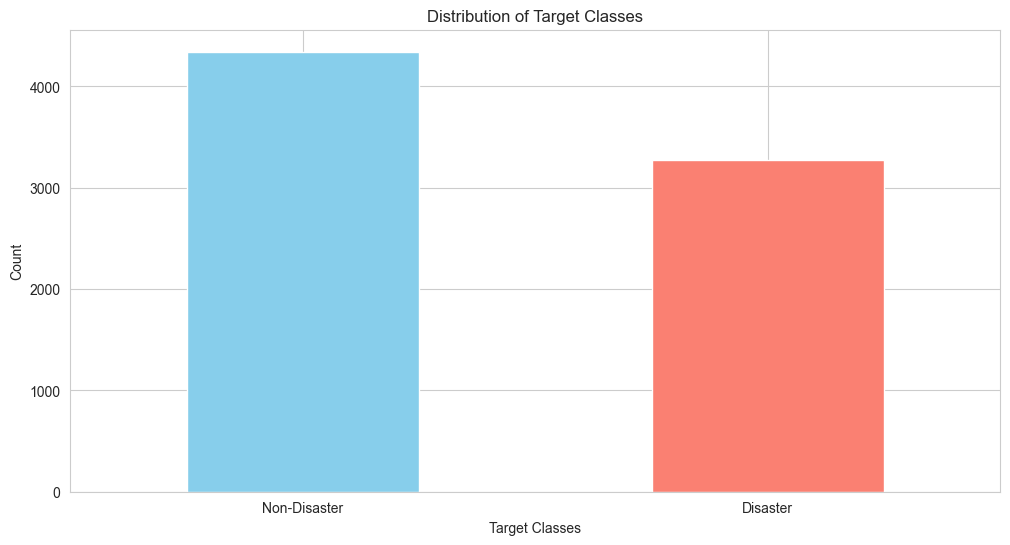

In [148]:
plt.figure(figsize=(12, 6))
target_counts.plot(kind="bar", color=["skyblue", "salmon"])

plt.title("Distribution of Target Classes")
plt.xlabel("Target Classes")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Disaster", "Disaster"], rotation=0)
plt.show()
logger.info("Target distribution plotted.")


### Univariate Analysis

This section examines individual variables in the dataset to understand their distribution, frequency, and overall structure.

The analysis focuses on:
- the distribution of the target classes
- the frequency of commonly occurring keywords
- the variation in tweet text length

This helps build a basic understanding of the dataset before comparing variables with one another.

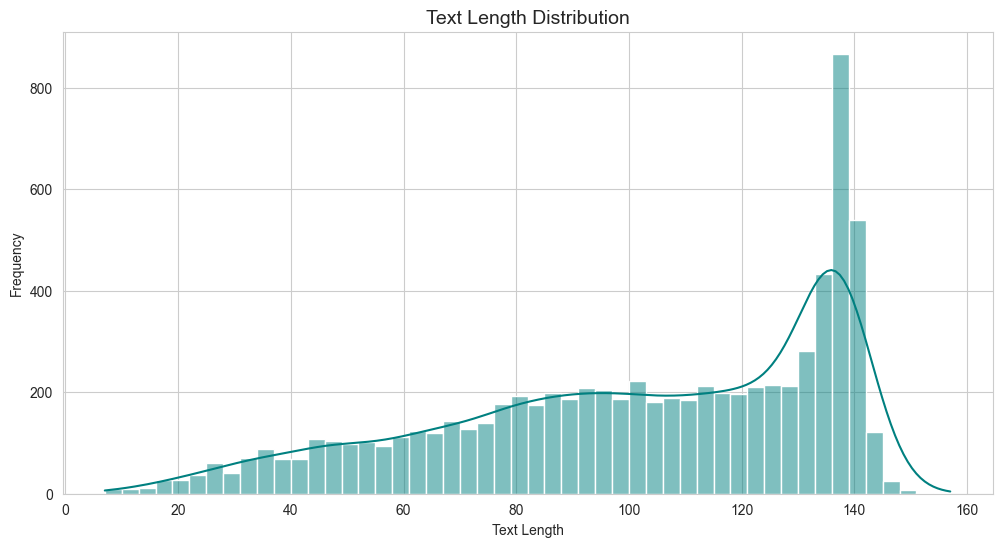

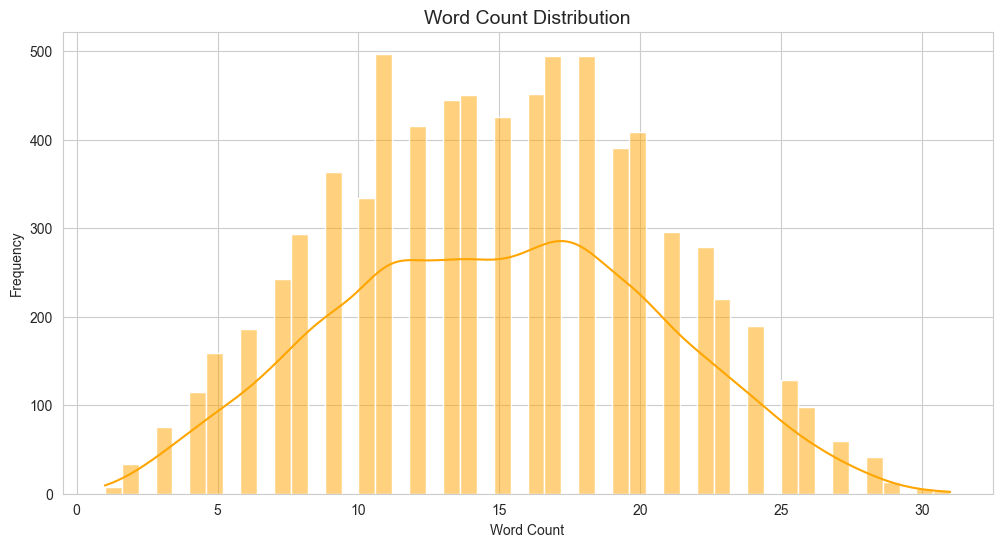

In [149]:
# Text length
plt.figure(figsize=(12, 6))

df['text_length'] = df['text'].apply(len)
sns.histplot(
    df['text_length'],
    bins=50,
    kde=True,
    color="teal"
)

plt.title('Text Length Distribution', fontsize=14)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# Word count
plt.figure(figsize=(12, 6))
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(
    df['word_count'],
    bins=50,
    kde=True,
    color="orange"
)

plt.title('Word Count Distribution', fontsize=14)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### Bivariate Analysis

Analyze relationship between features and target variable.

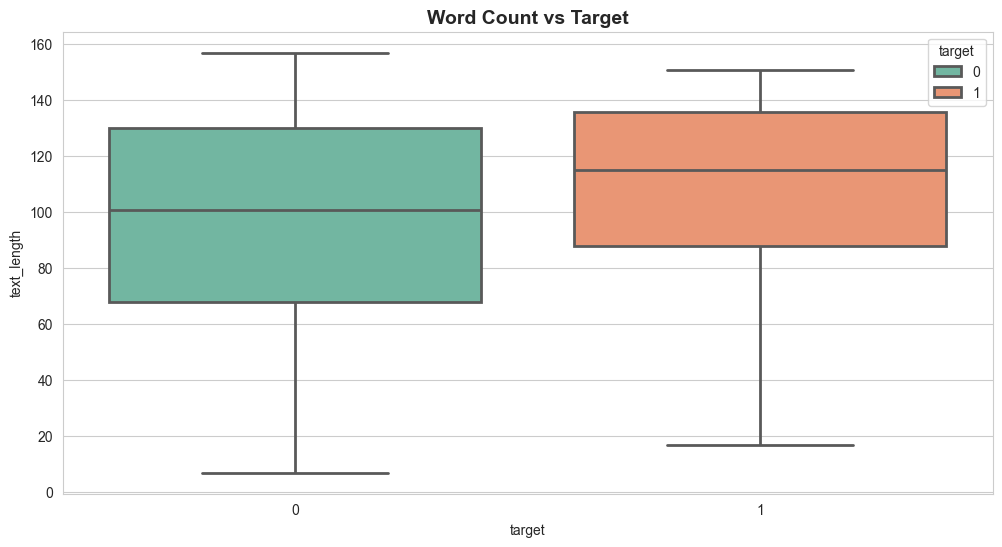

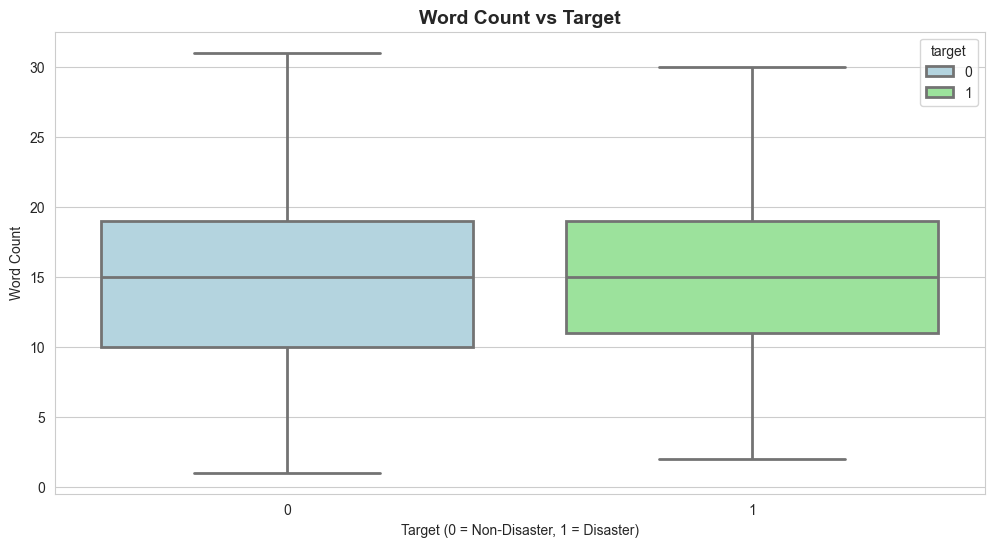

In [150]:
# Text length vs target
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="target",
    y="text_length",
    data=df,
    hue="target",
    palette="Set2",
    showfliers=False,
    linewidth=2
)
plt.title('Word Count vs Target', fontsize=14, fontweight='bold')
plt.show()

# Word count vs target
# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='target',
    y='word_count',
    data=df,
    hue="target",
    palette=["lightblue", "lightgreen"],
    showfliers=False,
    linewidth=2
)

plt.title('Word Count vs Target', fontsize=14, fontweight='bold')
plt.xlabel("Target (0 = Non-Disaster, 1 = Disaster)")
plt.ylabel("Word Count")

plt.show()

#### Multivariate Analysis

Analyze relationships among multiple features together.

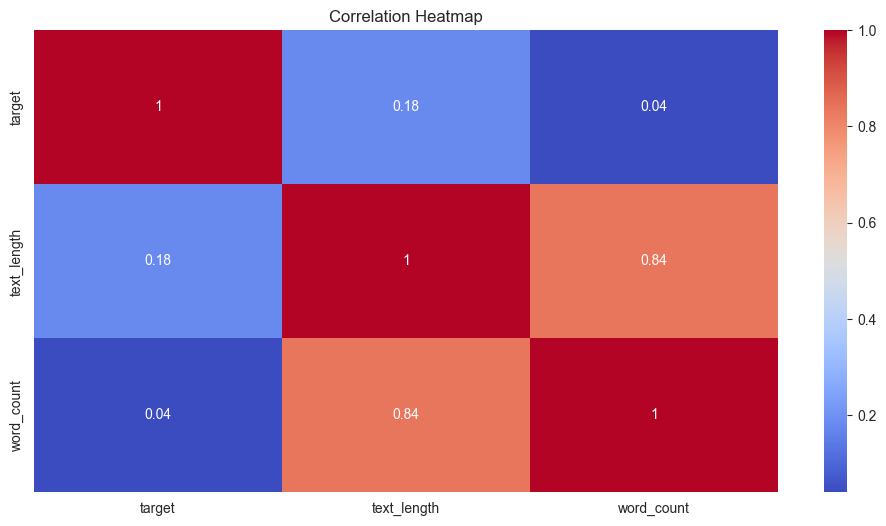

In [151]:

plt.figure(figsize=(12, 6))
features = df[['target', 'text_length', 'word_count']]

sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Fill missing text (if any)

In [152]:
df["text"] = df["text"].fillna("")
logger

<Logger __main__ (INFO)>

#### Top 20 Most Frequent Keywords

This section displays the 20 most frequently occurring keywords in the dataset.

- Missing values in the `keyword` column are replaced with `"missing"` for analysis
- The frequency of each keyword is then counted
- The top 20 most common keywords are selected for inspection

This summary helps identify the most repeated disaster-related terms and highlights how often keyword information is unavailable.


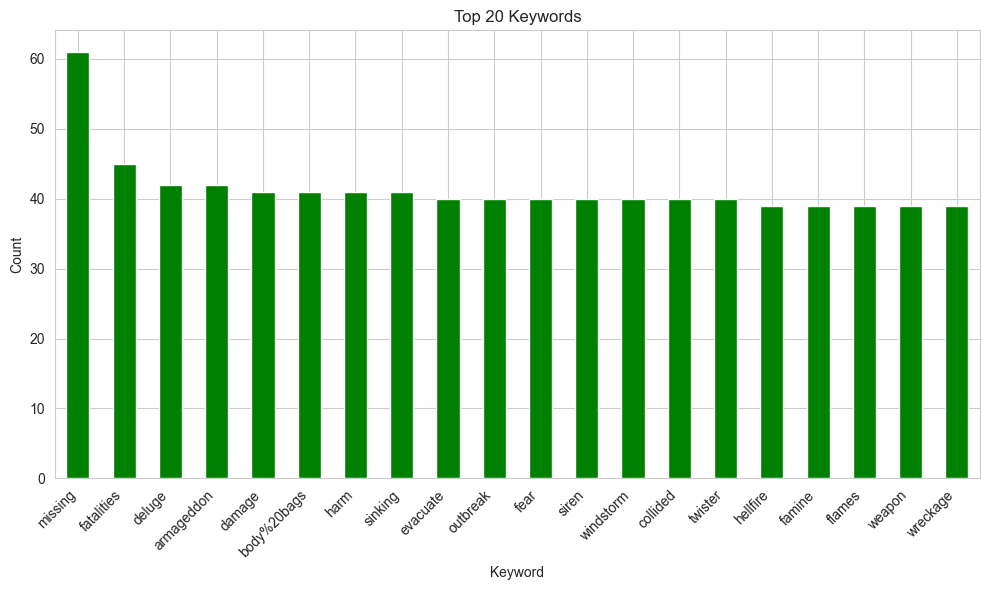

In [153]:
top_keywords = (
    df["keyword"]
    .fillna("missing")
    .value_counts()
    .head(20)
)
logger.info("Top 20 keywords:\n%s", top_keywords)

plt.figure(figsize=(10, 6))
top_keywords.plot(kind="bar", color="green")

plt.title("Top 20 Keywords")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
logger.info("Top 20 keywords plotted.")

#### Adding useful features as a matrix
Here we are adding additional information regarding the data present inside the dataset. Information is shown below:

In [154]:
# Add a few useful EDA features
logger.info("Creating EDA features...")
df["text_length_chars"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().apply(len)
df["has_hashtag"] = df["text"].astype(str).str.contains(r"#")
df["has_mention"] = df["text"].astype(str).str.contains(r"@")
df["has_url"] = df["text"].astype(str).str.contains(r"http|www", case=False)

df[["text_length_chars", "word_count", "has_hashtag", "has_mention", "has_url"]].head()
logger.info("EDA features created.")

#### **EDA Summary by Target Class**

The following summary shows the average text and engagement-related features for each target class.

- `text_length_chars`: average number of characters in the tweet
- `word_count`: average number of words in the tweet
- `has_hashtag`: average presence of hashtags in tweets
- `has_mention`: average presence of user mentions in tweets
- `has_url`: average presence of URLs in tweets

Here, `target = 0` represents non-disaster tweets and `target = 1` represents disaster tweets.


In [155]:
logger.info("Summarizing EDA features by target class...")
columns_to_summarize = [
    "text_length_chars",
    "word_count",
    "has_hashtag",
    "has_mention",
    "has_url"
]

eda_summary = df.groupby("target")[columns_to_summarize].mean()
logger.info("EDA summary by target class:\n%s", eda_summary)

#### Plotting the Summary on a bar graph

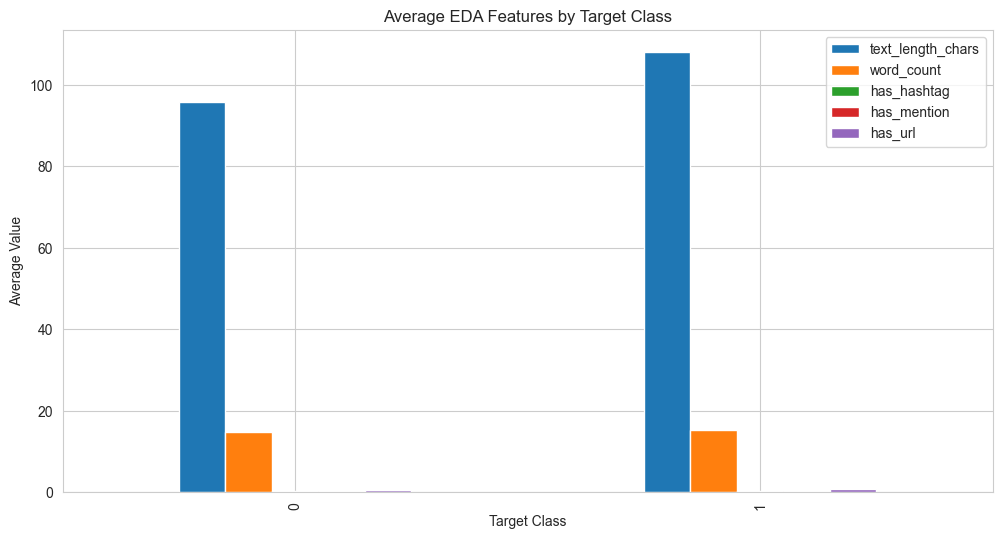

In [156]:
logger.info("EDA summary by target class:\n%s", eda_summary)
eda_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Average EDA Features by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Average Value")
plt.show()
logger.info("Features plotted by target class.")

#### Density Distribution of Tweet Length

This plot illustrates the distribution of tweet lengths, measured in characters, for disaster and non-disaster tweets.

- The curve for `Non-Disaster` represents tweets labeled as `0`
- The curve for `Disaster` represents tweets labeled as `1`
- The x-axis shows the number of characters in each tweet
- The y-axis represents the density of observations

This visualization helps identify how tweet lengths are distributed across the two classes and whether one class tends to contain longer or shorter tweets.

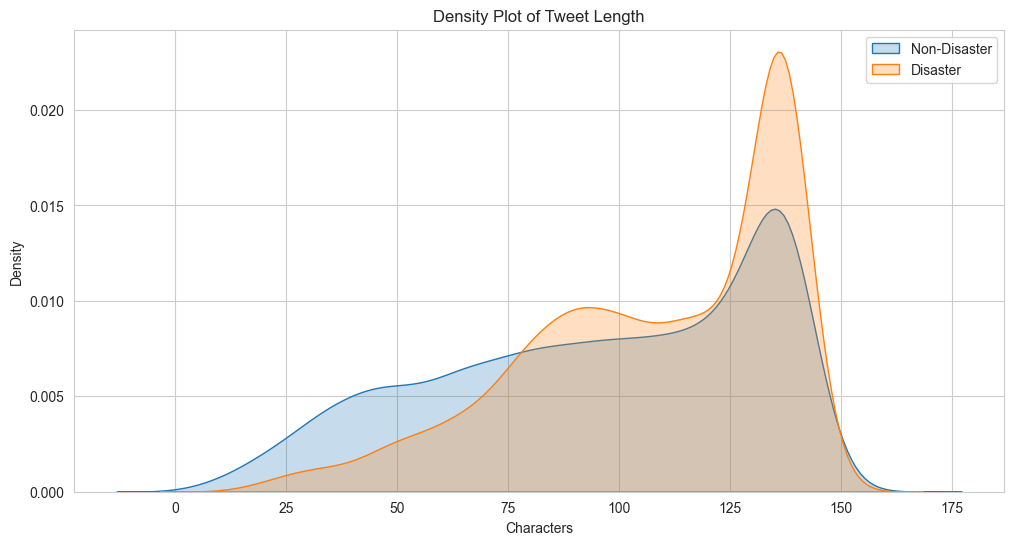

In [157]:
logger.info("Plotting density plot of tweet length by target class...")
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df[df["target"] == 0],
    x="text_length_chars",
    label="Non-Disaster",
    fill=True
)

sns.kdeplot(
    data=df[df["target"] == 1],
    x="text_length_chars",
    label="Disaster",
    fill=True
)

plt.title("Density Plot of Tweet Length")
plt.xlabel("Characters")
plt.ylabel("Density")
plt.legend()
plt.show()
logger.info("Density plot of tweet length by target class plotted.")

#### Cleaning Dataset using functions
Here we will do the following things:
- Lowercase the text
- Remove the URLs
- Remove the HTML tags
- Remove punctuation
- Remove numbers
- Remove special characters
- Tokenization
- Remove stopwords + stemming

In [158]:
def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove mentions
    text = re.sub(r"@\w+", "", text)
    
    # Remove hashtag symbol (keep word)
    text = re.sub(r"#", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

#### Applying the cleaning process

In [159]:
logger.info("Cleaning text data with clean_text function...")
df["clean_text"] = df["text"].apply(clean_text)
logger.info("Text data cleaned.")
df[["text", "clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


#### Tokenization of Cleaned Text

In this step, the cleaned tweet text is split into individual tokens using a space-based approach.

- Each tweet in the `clean_text` column is divided into separate words
- The resulting tokens are stored in a new column called `tokens`
- This makes the text easier to inspect and prepares it for later NLP tasks

The output below shows a preview of the cleaned text alongside its tokenized representation.

In [160]:
# Simple tokenized version (space-based)
logger.info("Tokenizing clean text data...")
df["tokens"] = df["clean_text"].str.split()
logger.info("Text cleaning and tokenization completed.")
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place..."
3,people receive wildfires evacuation orders in ...,"[people, receive, wildfires, evacuation, order..."
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala..."


#### Text Length Comparison (Before vs After Cleaning)

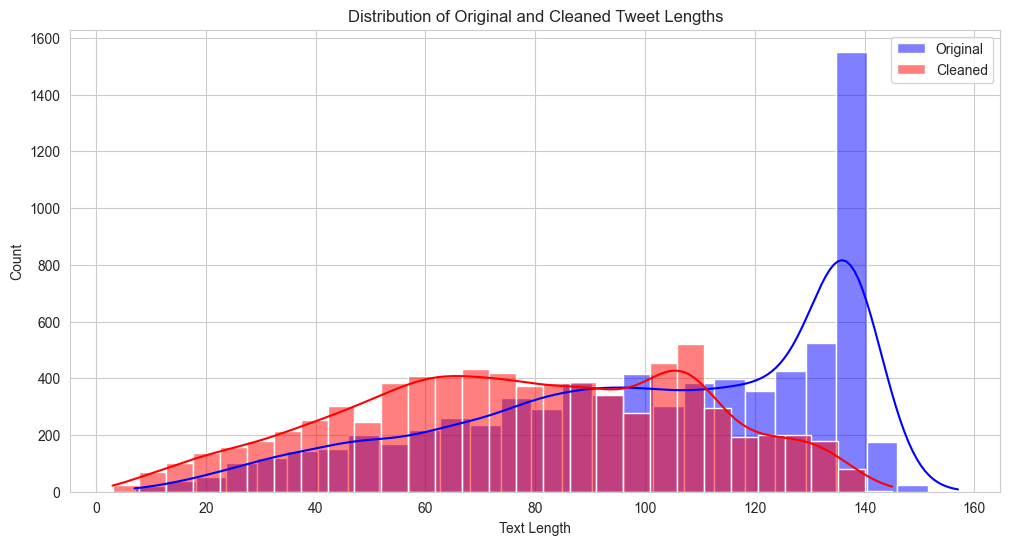

In [161]:
logger.info("Analyzing text length distribution before and after cleaning...")
df["original_length"] = df["text"].astype(str).apply(len)
df["clean_length"] = df["clean_text"].astype(str).apply(len)

plt.figure(figsize=(12, 6))

sns.histplot(df["original_length"], color="blue", label="Original", kde=True, alpha=0.5)
sns.histplot(df["clean_length"], color="red", label="Cleaned", kde=True, alpha=0.5)

plt.title("Distribution of Original and Cleaned Tweet Lengths")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.legend()
plt.show()
logger.info("Text length distribution before and after cleaning plotted.")


In [162]:
logger.info("==== DATA PREPARATION PIPELINE COMPLETED ====")
df.to_csv("../data/train_prepared.csv", index=False)
logger.info("Prepared data saved to: %s", "../data/train_prepared.csv")